# Notebook


## 1. Setup

In [1]:
import sys
from pathlib import Path

# Racine du projet : remonte depuis cwd jusqu'a trouver run_pipeline.py
# (robuste a jupyter lance depuis project/ ou un autre sous-dossier)
def _find_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "run_pipeline.py").exists():
            return p
    return start

ROOT = _find_root(Path.cwd())

# Ajoute project/ au sys.path pour importer notebook_tools.
# notebook_tools fait ensuite son propre bootstrap complet via _paths.
_project = str(ROOT / "project")
if _project not in sys.path:
    sys.path.insert(0, _project)

from notebook_tools import (
    RUNS_DIR,
    build_dataset, regroup_images,
    build_yolo_box, show_sanity,
    build_lard_box, show_sanity_lard,
    build_xplane_config, build_params_trace,
    build_video,
)
from runs import find_runs  # utilise dans la cellule "Lister les runs"

print(f"ROOT     = {ROOT}")
print(f"RUNS_DIR = {RUNS_DIR}  (exists={RUNS_DIR.exists()})")

ROOT     = c:\Users\Sr-Sh\Desktop\LARD-LAAS-TAF
RUNS_DIR = C:\Users\Sr-Sh\Desktop\LARD-LAAS-TAF\runs  (exists=True)


## 2. Generate (Phase 1 — TAF seul, offline)

Equivalent CLI : `py run_pipeline.py generate -n N`

Sample N scenarios via TAF/z3 et ecrit `runs/<ICAO_RWY>/` avec `.yaml`,
`poses_cam_export.json`, `fault_profile.json`, `weather_profile.json`.
Pas besoin de X-Plane. `nb_scenarios=None` => valeur de `project/settings.xml`.

In [8]:
from Generate import generate_runs

# generate_runs(nb_scenarios=5, quiet=True)
generate_runs(nb_scenarios=1, quiet=False);

 PHASE 1 : Generation TAF
[Pipeline] Generation : generation_02/
Miscellaneous::file_check() -> "Export.py" does not exist
[Generate] Template : templates/base_template.xml
[Generate] Sortie   : ../output/
[Generate] Scenarios: 1

parsing template: templates/base_template.xml
Current path: ../output/scenario_0/
Miscellaneous::file_check() -> "../output/scenario_0/scenario_0.xml" does not exist
Create new test case: scenario.xml
--------------------------------------------------------------------------------
additional contraint(s): 
['var_127_0 == 2000.0', 'var_133_0 == 1351.86942', 'var_128_0 == 283.64021']
--------------------------------------------------------------------------------
--------------------------------------------------------------------------------
additional contraint(s): 
['var_49_0 == 100.0', 'var_48_0 == 0.0', 'var_90_0 == 0.0', 'var_55_0 == 100.0', 'var_72_0 == 0.0', 'var_111_0 == 0.0', 'var_82_0 == 100.0', 'var_60_0 == 1', 'var_36_0 == 0.0', 'var_33_0 == 0.0', 

## 3. Render (Phase 2 — Rendu X-Plane + fautes capteur)

Equivalent CLI :
- `py run_pipeline.py render LFPO_24 --xplane-dir "C:/X-Plane 12"`
- `py run_pipeline.py render --all --xplane-dir "C:/X-Plane 12"`

Suppose que la Phase 1 (`generate`) a deja ete faite. Necessite X-Plane 12
lance (mode fenetre, scaling 100%). Sortie : `footage/`, `degraded/`.
Le GT LARD n'est PAS genere ici (il l'est en Phase 3, juste avant l'IoU).

In [7]:
import xml.etree.ElementTree as ET
from runs import render_runs

# Repertoire X-Plane lu depuis project/settings.xml
_settings = {p.attrib["name"]: p.attrib["value"]
             for p in ET.parse(ROOT / "project" / "settings.xml").getroot()}
XPLANE_DIR = _settings["xplane_dir"]

# Un seul run :
# render_runs(run_name="LFPO_24", xplane_dir=XPLANE_DIR)

# Tous les runs :
render_runs(all_runs=True, xplane_dir=XPLANE_DIR);

 PHASE 2 : Rendu X-Plane + fautes capteur

[Pipeline] 1 run(s) a rendre

--------------------------------------------------
 Run : generation_01/KLAX_25R
--------------------------------------------------

  [Image] Rendu + fautes + GT pour KLAX_25R

  [XPLANE] Rendu de KLAX_25R...
  [XPLANE] Rendu de KLAX_25R (272 frames)...
  [XPLANE] Connexion UDP -> 127.0.0.1:49000
  [XPLANE] Fenetre resizee -> 1024x1024
  [XPLANE] Fenetre trouvee: 'X-Plane' rect=(276, 50, 1572, 1113)
  [XPLANE] Client rect: left=284 top=81 right=1564 bottom=1105
  [XPLANE] Desktop virtuel: {'left': 0, 'top': 0, 'width': 4480, 'height': 1440}
  [XPLANE] Capture : 1280x1024
  [XPLANE] Fenetre reelle: 1280x1024, fact=1.25x1.00
  [XPLANE] FOV programme: H=71.6° V=60.0° (readback: H=71.6° V=60.0°)
  [XPLANE] Plugin XPPython3 weather OK
  [WEATHER] Injecte : clouds=Cirrus(30%), vis=23526m, avion_max=147m, nuages=3660-6404m MSL
  [WEATHER] Chargement textures + stabilisation nuages 15.0s...
  [WEATHER] Stabilisation term

## 4. Evaluate (Phase 3 — GT LARD + YOLO + IoU, sans X-Plane)

Equivalent CLI :
- `py run_pipeline.py evaluate LFPO_24`
- `py run_pipeline.py evaluate --all`

Suppose que `footage/` ou `degraded/` existe deja (Phase 2 faite). Genere
le GT LARD a la volee (`*_labels.csv`), puis YOLO predict + IoU. Re-executable
a volonte avec d'autres poids/seuils sans re-rendre.

In [8]:
from runs import evaluate_runs

# Un seul run :
# evaluate_runs(run_name="LFPO_24")

# Tous les runs :
evaluate_runs(all_runs=True);

 PHASE 3 : Detection YOLO + IoU

[Pipeline] 1 run(s) a evaluer

--------------------------------------------------
 Run : generation_01/KLAX_25R
--------------------------------------------------

  [Eval] Detection + IoU pour KLAX_25R

  [YOLO] Prediction sur 272 images depuis footage/ (KLAX_25R)...
Prediction sur 272 images avec yolov8nTest.pt

image 1/272 C:\Users\Sr-Sh\Desktop\LARD-LAAS-TAF\runs\generation_01\KLAX_25R\footage\KLAX_25R_000.jpg: 512x512 1 runway, 18.7ms
image 2/272 C:\Users\Sr-Sh\Desktop\LARD-LAAS-TAF\runs\generation_01\KLAX_25R\footage\KLAX_25R_001.jpg: 512x512 1 runway, 10.3ms
image 3/272 C:\Users\Sr-Sh\Desktop\LARD-LAAS-TAF\runs\generation_01\KLAX_25R\footage\KLAX_25R_002.jpg: 512x512 1 runway, 13.2ms
image 4/272 C:\Users\Sr-Sh\Desktop\LARD-LAAS-TAF\runs\generation_01\KLAX_25R\footage\KLAX_25R_003.jpg: 512x512 1 runway, 14.6ms
image 5/272 C:\Users\Sr-Sh\Desktop\LARD-LAAS-TAF\runs\generation_01\KLAX_25R\footage\KLAX_25R_004.jpg: 512x512 1 runway, 7.8ms
image 6/272 

## 5. Lister les runs disponibles

In [9]:
runs = find_runs(all_runs=True)
for r in runs:
    print(f"  - {r.name}")
print(f"\n{len(runs)} run(s) trouve(s).")

  - KLAX_25R
  - KBNA_13

2 run(s) trouve(s).


## 6. Creation du dataset (arborescence par piste / scenario)

Format aligne sur le CSV LARD natif (sous-ensemble : colonnes pertinentes pour
notre pipeline). Les valeurs `yaw`, `pitch`, `roll`, `slant_distance`,
`along_track_distance`, `height_above_runway`, et la bbox `x_TR..y_BR` sont
copiees telles quelles depuis les *_labels.csv (unites LARD : degres, NM, ft, px).

```
dataset/
├── metadata.csv                         # toutes pistes, tous scenarios
└── <ICAO_RWY>/                          # ex: KPDX_10L
    ├── metadata.csv                     # tous scenarios de cette piste
    └── <ICAO_RWY>_<NNN>/                # ex: KPDX_10L_001
        ├── metadata.csv                 # ce scenario uniquement
        └── images/000000.jpg ...
```

Colonnes : `height, width, type, scenario, airport, runway, time, time_fps,
weather, yaw, pitch, roll, slant_distance, along_track_distance,
height_above_runway, lateral_path_angle, vertical_path_angle,
x_TR, y_TR, x_TL, y_TL, x_BL, y_BL, x_BR, y_BR, image`.

Necessite que la generation ait ete faite avec le nouveau Export.py (ajoute
`template_file_name` dans `poses_cam_export.json` -> colonne `weather`).

In [10]:
build_dataset()

Dataset : C:\Users\Sr-Sh\Desktop\LARD-LAAS-TAF\runs\dataset
  KLAX_25R                  <- footage  ( 272 imgs) [ok -> KLAX_25R/KLAX_25R_001]
  KBNA_13                   <- footage  (   0 imgs) [absent]
Total : 272 images, 2 piste(s)
Metadata racine : C:\Users\Sr-Sh\Desktop\LARD-LAAS-TAF\runs\dataset\metadata.csv (272 lignes)


{'KLAX_25R': ('footage', 272, 'ok -> KLAX_25R/KLAX_25R_001'),
 'KBNA_13': ('footage', 0, 'absent')}

In [11]:
regroup_images()

Regroupement : C:\Users\Sr-Sh\Desktop\LARD-LAAS-TAF\runs\dataset_regroup
  KLAX_25R                   272 imgs
Total : 272 images, 1 piste(s)


## 7. Generer `yolo_box/` (images avec bbox YOLO dessinees)

Lit `predictions.csv` du run, dessine les bbox sur les images sources
(`degraded/` en priorite, sinon `footage/`) et ecrit dans `runs/<run>/yolo_box/`.

Usage :
- `build_yolo_box("LFPO_24")` : une seule run
- `build_yolo_box()`           : toutes les runs

In [2]:
# build_yolo_box("LFPO_24")  # un seul run
build_yolo_box()

Results saved to C:\Users\Sr-Sh\Desktop\LARD-LAAS-TAF\runs\generation_01\KLAX_25R\yolo_box
  KLAX_25R -> yolo_box/
  [skip] KBNA_13 : pas d'images dans footage/


## 8. Sanity check : 3 images avec bbox YOLO 

Affiche première / milieu / dernière image d'un run avec les bbox YOLO dessinées
 (`degraded/` prio sinon `footage/`).

Usage : `show_sanity("LFPO_24")` ou `show_sanity()` (= premier run trouvé).

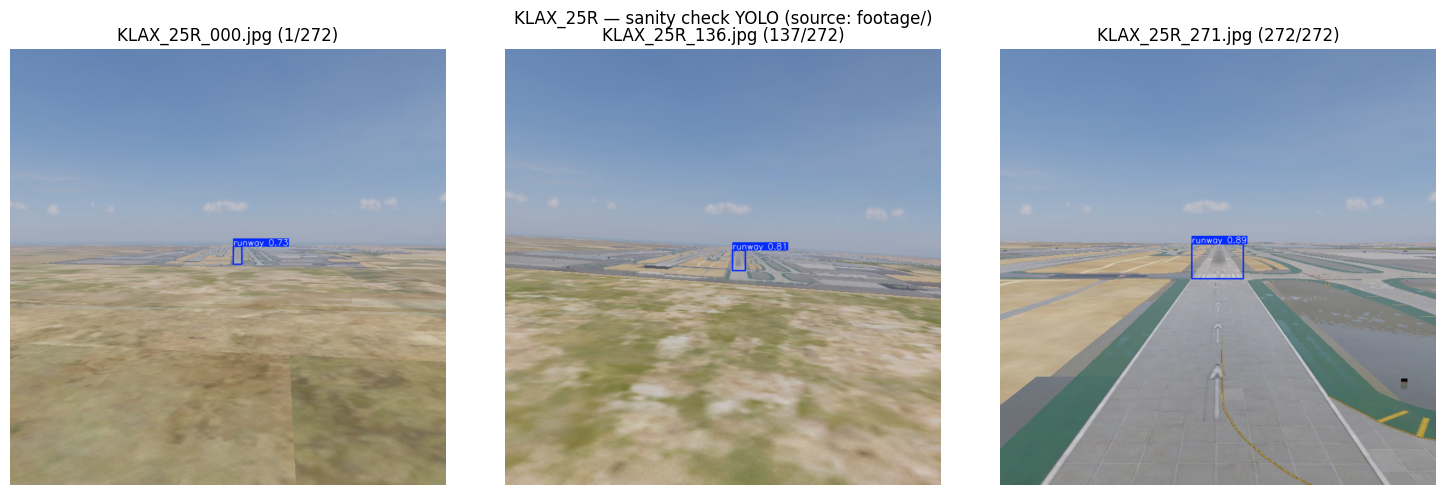

In [3]:
# show_sanity("LFPO_24")  # un run cible
show_sanity()

## 9. Generer `lard_box/` (images avec bbox GT LARD dessinées)

Usage : `build_lard_box("LFPO_24")` ou `build_lard_box()` (toutes les runs).

In [4]:
# build_lard_box("LFPO_24")  # un seul run
build_lard_box()

  [GT-VIS] 272 images annotees dans lard_box/
  KLAX_25R -> lard_box/
  [skip] KBNA_13 : pas d'images dans footage/


## 10. Sanity check : 3 images avec bbox GT LARD 

Affiche première / milieu / dernière image d'un run avec les 4 coins GT LARD
(`degraded/` prio sinon `footage/`).

Usage : `show_sanity_lard("LFPO_24")` ou `show_sanity_lard()` (= premier run).

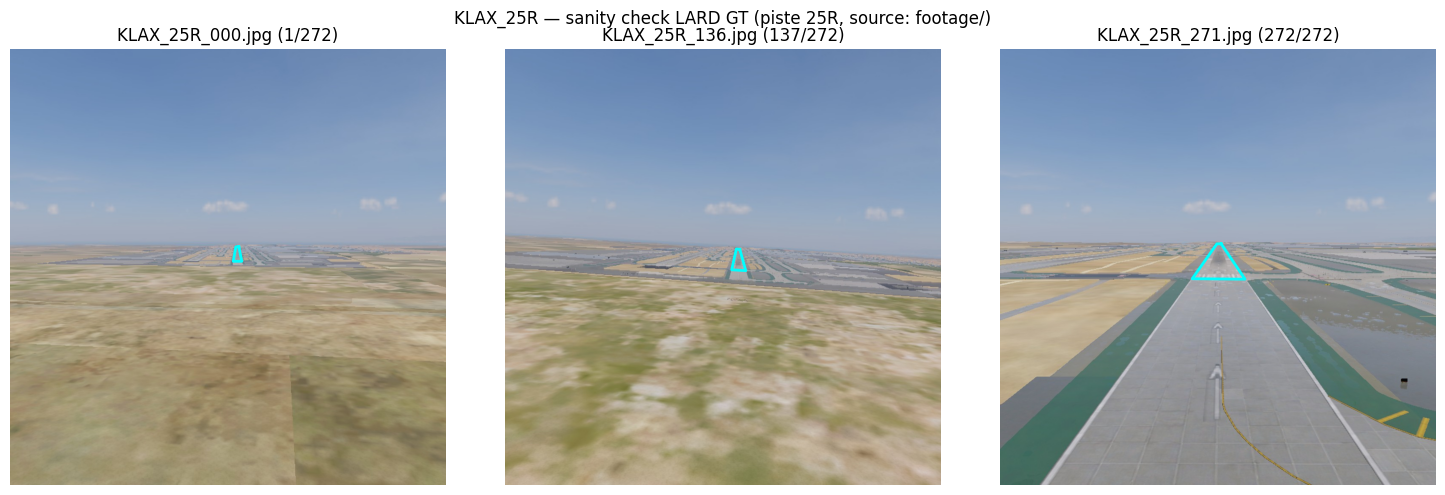

In [5]:
# show_sanity_lard("LFPO_24")  # un run cible
show_sanity_lard()

## 11. Generer `xplane_config.json`

Reconstruit `runs/<run>/xplane_config.json` depuis le yaml (résolution pré-crop, FOV) et
`weather_profile.json` (status). `pilot_eye_*` (dépend de l'avion choisi sur XPLANE12)

Usage : `build_xplane_config("LFPO_24")` ou `build_xplane_config()` (toutes).

In [6]:
# build_xplane_config("LFPO_24")  # un seul run
build_xplane_config()

  KLAX_25R -> xplane_config.json (1024x1024, weather=ok)
  KBNA_13 -> xplane_config.json (1024x1024, weather=ok)


## 12. Generer `params_trace.xml`

Reconstruit `runs/<run>/params_trace.xml` 

Usage : `build_params_trace("LFPO_24")` ou `build_params_trace()` (toutes).

In [7]:
# build_params_trace("LFPO_24")  # un seul run
build_params_trace()

  KLAX_25R -> params_trace.xml
  KBNA_13 -> params_trace.xml


## 13. Générer une video MP4 du run/des runs

Concatene les images du run (`degraded/` prio sinon `footage/`) en un MP4 (fps .xml)

Usage :
- `build_video("LFPO_24")` : une seule run
- `build_video()`           : toutes les runs
- `build_video(source="footage")` : force la source (`footage` ou `degraded`)

In [8]:
# build_video("LFPO_24")              # un seul run
# build_video(source="footage")        # force la source
build_video()

  KLAX_25R -> KLAX_25R.mp4  (272 frames @ 12fps, footage/)
  [skip] KBNA_13 : pas d'images dans footage/
